In [1]:
import pandas as pd
import matplotlib.pyplot as plt



In [2]:
data = pd.read_csv("heart.csv")

In [3]:
numerical_columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal"
]

In [4]:
def histogram_values(values, number_of_bins):

    values = list(values)

    minimum = values[0]
    maximum = values[0]

    for value in values:

        if value < minimum:
            minimum = value

        if value > maximum:
            maximum = value


    bin_width = (maximum - minimum) / number_of_bins


    # For columns such as sex where min and max can be close
    if bin_width == 0:
        bin_width = 1


    bins = []

    for i in range(number_of_bins + 1):

        bin_value = minimum + (i * bin_width)

        bins.append(bin_value)


    frequencies = [0] * number_of_bins


    for value in values:

        placed = False

        for i in range(number_of_bins):

            if value >= bins[i] and value < bins[i + 1]:

                frequencies[i] = frequencies[i] + 1

                placed = True

                break


        if placed == False:

            if value == maximum:

                frequencies[number_of_bins - 1] = frequencies[number_of_bins - 1] + 1


    return bins, frequencies

In [5]:
bins, frequencies = histogram_values(
    data["chol"],
    10
)

print("Bins:", bins)

print("Frequencies:", frequencies)

Bins: [126.0, 169.8, 213.6, 257.4, 301.2, 345.0, 388.79999999999995, 432.59999999999997, 476.4, 520.2, 564.0]
Frequencies: [42, 247, 359, 231, 120, 10, 13, 0, 0, 3]


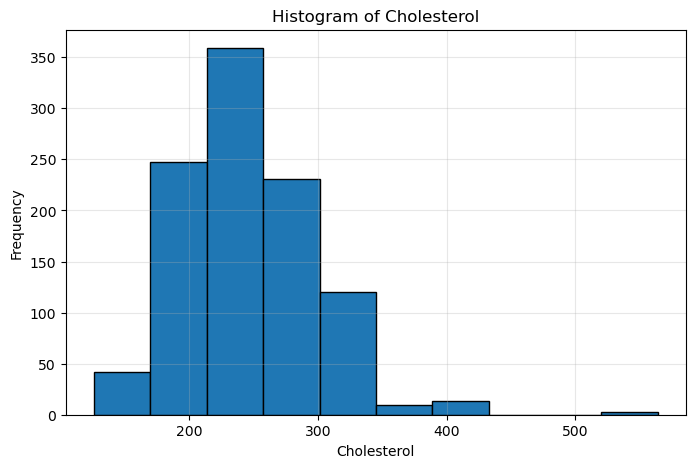

In [7]:
bins, frequencies = histogram_values(
    data["chol"],
    10
)

bin_centers = []

for i in range(len(frequencies)):

    center = (bins[i] + bins[i + 1]) / 2

    bin_centers.append(center)


bin_width = bins[1] - bins[0]


plt.figure(figsize=(8, 5))

plt.bar(
    bin_centers,
    frequencies,
    width=bin_width,
    edgecolor="black"
)

plt.title("Histogram of Cholesterol")

plt.xlabel("Cholesterol")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

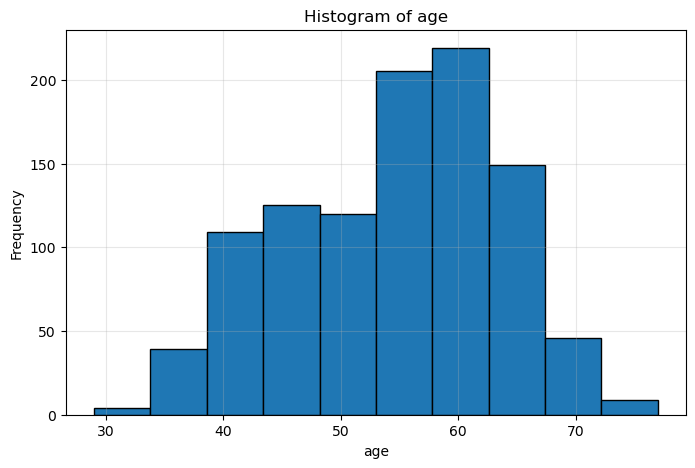

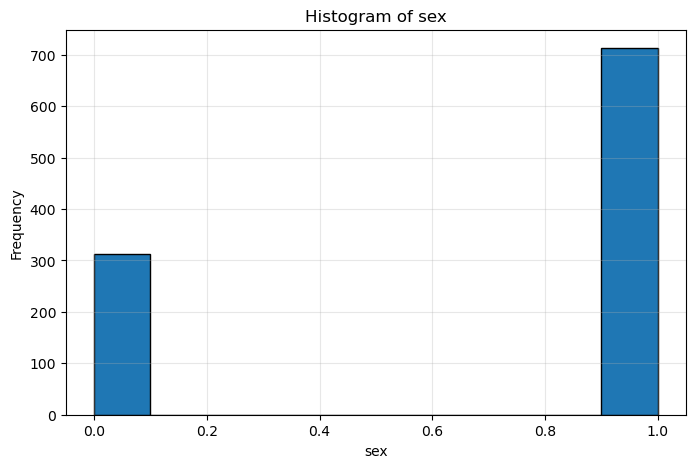

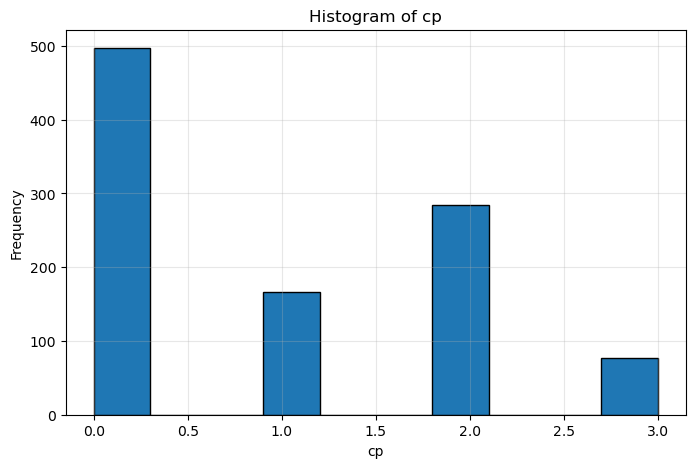

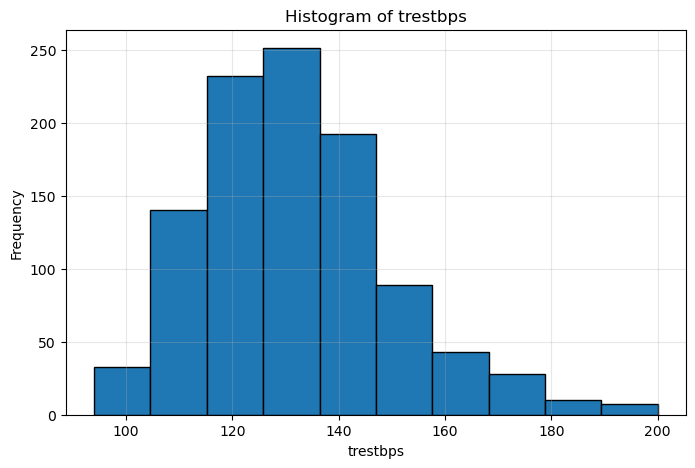

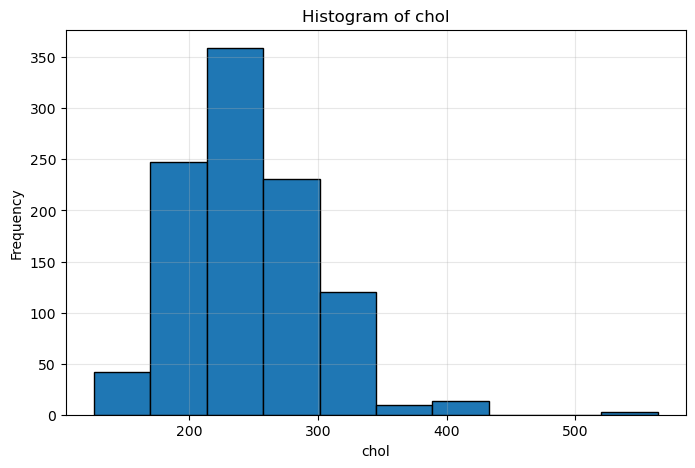

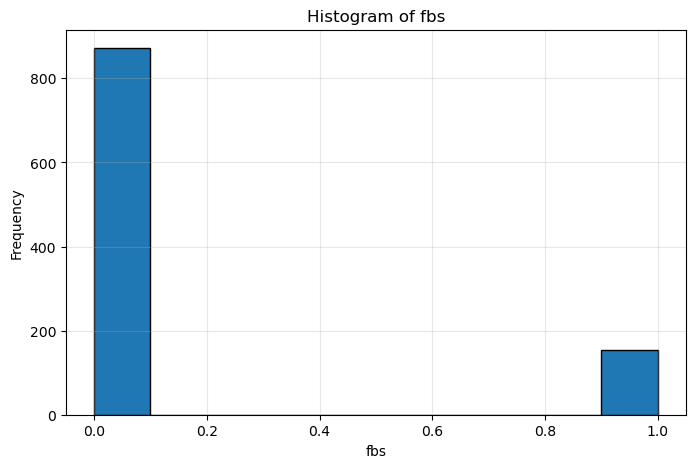

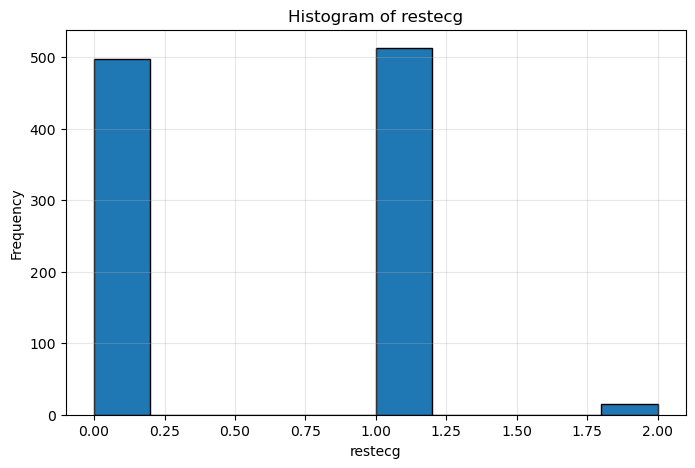

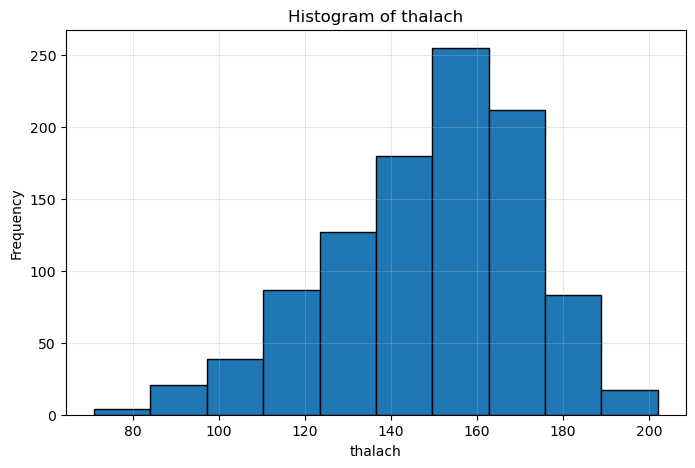

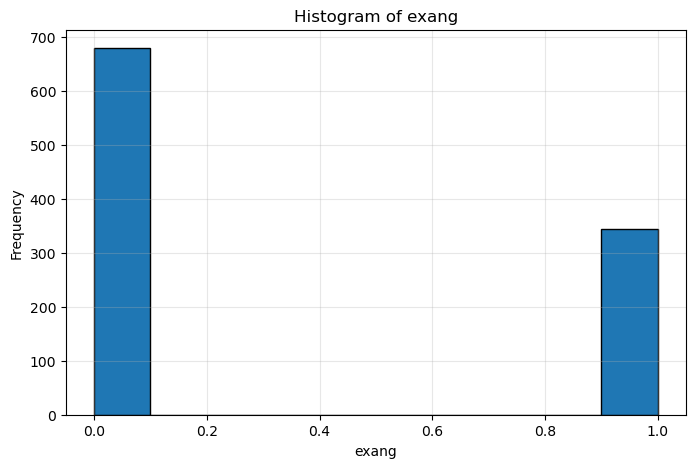

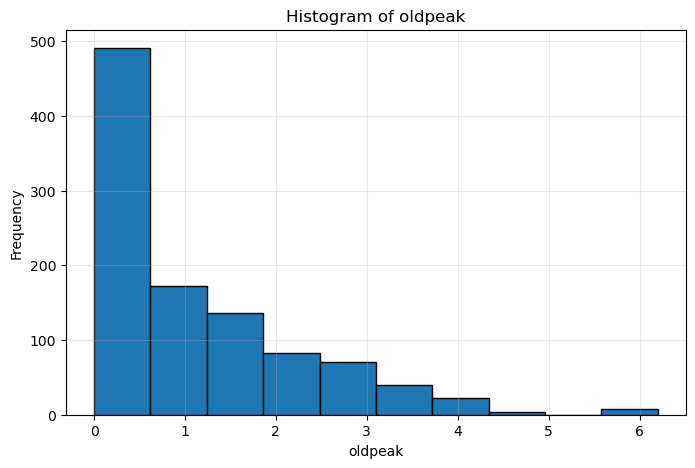

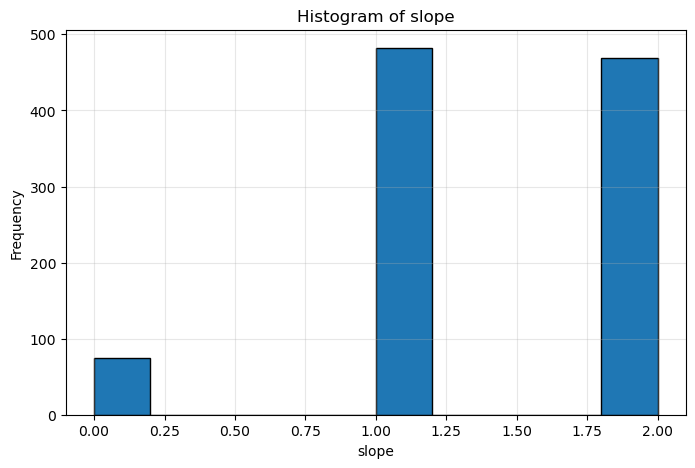

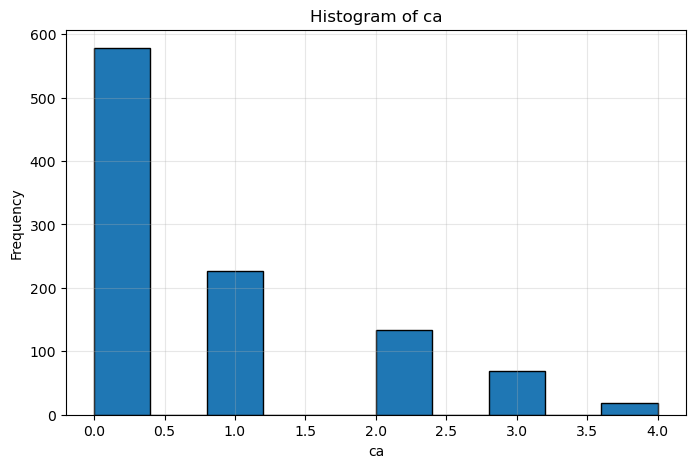

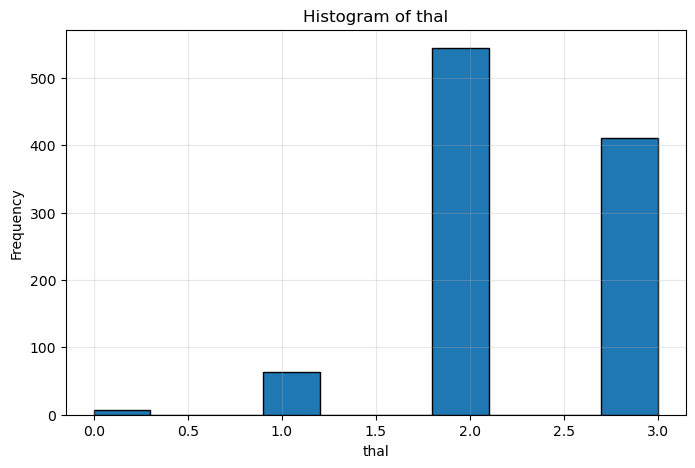

In [8]:
for column in numerical_columns:

    bins, frequencies = histogram_values(
        data[column],
        10
    )


    bin_centers = []

    for i in range(len(frequencies)):

        center = (
            bins[i] +
            bins[i + 1]
        ) / 2

        bin_centers.append(center)


    bin_width = bins[1] - bins[0]


    plt.figure(figsize=(8, 5))


    plt.bar(
        bin_centers,
        frequencies,
        width=bin_width,
        edgecolor="black"
    )


    plt.title(
        "Histogram of " + column
    )


    plt.xlabel(column)

    plt.ylabel("Frequency")

    plt.grid(alpha=0.3)

    plt.show()